# Предсказание стоимости услуг репетитора

Задача: предсказать среднюю стоимость услуг репетитора за минуту на основе различных данных о нём.

Признаки включают: предмет преподавания, рейтинг, количество отзывов, описание опыта, образование и пр.

In [220]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_STATE = 33
np.random.seed(RANDOM_STATE)

## Загрузка данных

In [221]:
train = pd.read_excel('train.xlsx')
test = pd.read_excel('test.xlsx')

print(f"Размер тренировочного набора: {train.shape}")
print(f"Размер тестового набора: {test.shape}")

Размер тренировочного набора: (4548, 28)
Размер тестового набора: (1516, 27)


In [222]:
train.head()

,Unnamed: 0,предмет,ФИО,tutor_head_tags,tutor_rating,tutor_reviews,description,experience_desc,Education_1,Desc_Education_1,Education_2,Desc_Education_2,Education_3,Desc_Education_3,Education_4,Desc_Education_4,Ученая степень 1,Ученое звание 1,status,experience,Desc_Education_5,Desc_Education_6,Education_5,Education_6,Ученая степень 2,Ученое звание 2,categories,mean_price
0,0,matematika,Репетитор по математике Емельянова Марина Вла...,"['Школьная программа', 'Подготовка к ЕГЭ', 'По...",5.0,2,Репетитор не предоставил о себе дополн...,NaN,Томский государственный университет им. В.В. ...,"Год окончания: 1990, Факультет: механико-мате...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Университетский преподаватель,31 год,NaN,NaN,NaN,NaN,NaN,NaN,"['Школьники с 5 по 9 класс', 'Школьники с 10 п...",16.666667
1,1,matematika,Репетитор по математике Назарова Анастасия Ан...,"['Школьная программа', 'Подготовка к ЕГЭ', 'По...",4.0,7,Репетитор не предоставил о себе дополн...,NaN,Вологодский государственный педагогический ун...,"Год окончания: 2017, Факультет: факультет при...",Череповецкий государственный университет,"Год окончания: 2023, Факультет: институт инфо...",NaN,NaN,NaN,NaN,NaN,NaN,Школьный преподаватель,8 лет,NaN,NaN,NaN,NaN,NaN,NaN,"['Школьники с 5 по 9 класс', 'Школьники с 10 п...",11.666667
2,2,informatika,Репетитор по информатике Мотроненко Инна Конст...,"['Школьная программа', 'Подготовка к ЕГЭ', 'По...",0.0,0,"Выезд за город: Балашиха-1, Балашиха-2...",Московская Школа (учитель ...,Московский городской педагогический университет,"Год окончания: 2008, Факультет: Математически...",Московский городской педагогический университ...,"Год окончания: 2014, Факультет: Безопасность ...",Российская таможенная академия,"Год окончания: 2011, Факультет: Экономический...",NaN,NaN,NaN,NaN,Школьный преподаватель,11 лет,NaN,NaN,NaN,NaN,NaN,NaN,"['Школьники с 5 по 9 класс', 'Школьники с 10 п...",23.333333
3,3,matematika,Репетитор по математике Логинова Елизавета Ал...,"['Школьная программа', 'Математический анализ'...",4.0,19,"Здравствуйте! Меня зовут Елизавета, о...",NaN,Санкт-Петербургский государственный университет,"Год окончания: 2021, Факультет: физический фа...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Частный преподаватель,5 лет,NaN,NaN,NaN,NaN,NaN,NaN,"['Школьники с 1 по 4 класс', 'Школьники с 5 по...",0.116667
4,4,matematika,Репетитор по математике Харланов Олег Викторо...,"['Школьная программа', 'Подготовка к ЕГЭ', 'По...",0.0,0,"Целеустремленный, ориентирован на резу...",преподавателем ...,Приазовский государственный технический униве...,"Год окончания: 2005, Факультет: Энергетически...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Частный преподаватель,19 лет,NaN,NaN,NaN,NaN,NaN,NaN,"['Школьники с 5 по 9 класс', 'Школьники с 10 п...",16.666667


In [223]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4548 entries, 0 to 4547
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        4548 non-null   int64  
 1   предмет           4548 non-null   object 
 2   ФИО               4548 non-null   object 
 3   tutor_head_tags   4548 non-null   object 
 4   tutor_rating      3959 non-null   float64
 5   tutor_reviews     4548 non-null   int64  
 6   description       4547 non-null   object 
 7   experience_desc   2171 non-null   object 
 8   Education_1       4548 non-null   object 
 9   Desc_Education_1  4472 non-null   object 
 10  Education_2       781 non-null    object 
 11  Desc_Education_2  777 non-null    object 
 12  Education_3       106 non-null    object 
 13  Desc_Education_3  105 non-null    object 
 14  Education_4       16 non-null     object 
 15  Desc_Education_4  16 non-null     object 
 16  Ученая степень 1  76 non-null     object 


In [224]:
train.columns.tolist()

['Unnamed: 0',
 'предмет',
 'ФИО',
 'tutor_head_tags',
 'tutor_rating',
 'tutor_reviews',
 'description',
 'experience_desc',
 'Education_1',
 'Desc_Education_1',
 'Education_2',
 'Desc_Education_2',
 'Education_3',
 'Desc_Education_3',
 'Education_4',
 'Desc_Education_4',
 'Ученая степень 1',
 'Ученое звание 1',
 'status',
 'experience',
 'Desc_Education_5',
 'Desc_Education_6',
 'Education_5',
 'Education_6',
 'Ученая степень 2',
 'Ученое звание 2',
 'categories',
 'mean_price']

## Исследование данных

Посмотрим на целевую переменную и основные признаки

In [225]:
print("Статистика целевой переменной mean_price:")
train['mean_price'].describe()

Статистика целевой переменной mean_price:


count    4548.000000
mean       16.197949
std        10.485108
min         0.041667
25%        10.000000
50%        15.000000
75%        20.888889
max       100.000000
Name: mean_price, dtype: float64

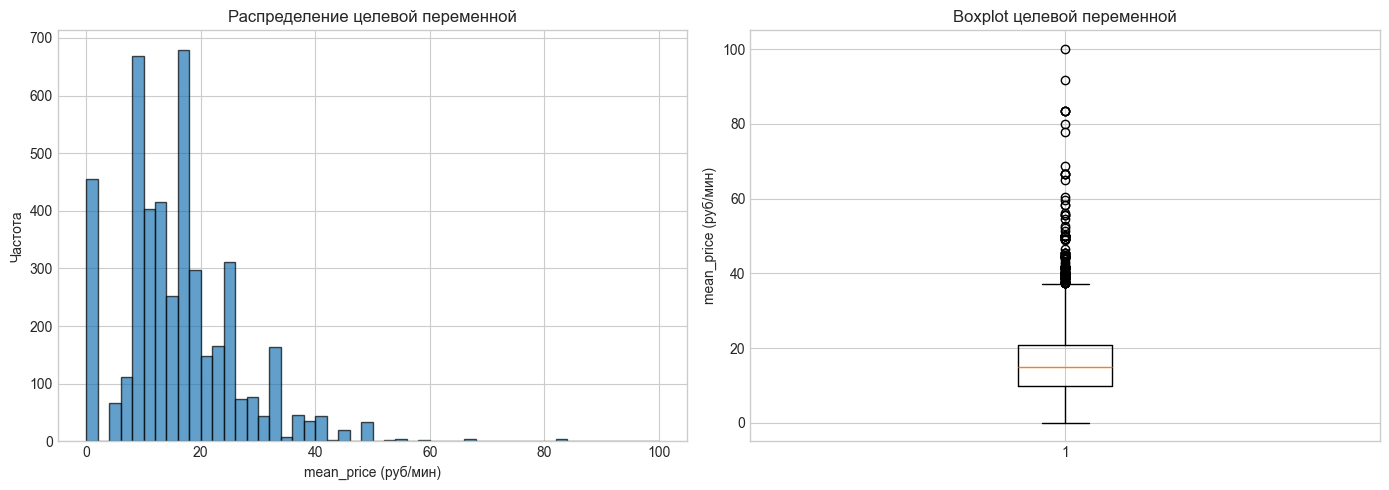


Скошенность (skewness): 1.31
Эксцесс (kurtosis): 4.56


In [226]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['mean_price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('mean_price (руб/мин)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение целевой переменной')

axes[1].boxplot(train['mean_price'])
axes[1].set_ylabel('mean_price (руб/мин)')
axes[1].set_title('Boxplot целевой переменной')

plt.tight_layout()
plt.show()

print(f"\nСкошенность (skewness): {train['mean_price'].skew():.2f}")
print(f"Эксцесс (kurtosis): {train['mean_price'].kurtosis():.2f}")

Распределение скошено вправо — большинство репетиторов берут умеренную плату, но есть дорогие специалисты.

In [227]:
print("Пропуски в данных (train):")
missing_train = train.isnull().sum()
missing_train[missing_train > 0].sort_values(ascending=False)

Пропуски в данных (train):


Ученое звание 2     4547
Ученая степень 2    4547
Education_6         4547
Desc_Education_6    4547
Education_5         4545
Desc_Education_5    4545
Desc_Education_4    4532
Education_4         4532
Ученое звание 1     4513
Ученая степень 1    4472
Desc_Education_3    4443
Education_3         4442
Desc_Education_2    3771
Education_2         3767
experience_desc     2377
tutor_rating         589
Desc_Education_1      76
experience            25
status                13
description            1
dtype: int64

In [228]:
print("Пропуски в данных (test):")
missing_test = test.isnull().sum()
missing_test[missing_test > 0].sort_values(ascending=False)

Пропуски в данных (test):


Ученое звание 2     1516
Education_6         1516
Desc_Education_6    1516
Ученая степень 2    1515
Education_5         1515
Desc_Education_5    1515
Education_4         1513
Desc_Education_4    1513
Ученое звание 1     1509
Ученая степень 1    1496
Desc_Education_3    1482
Education_3         1482
Desc_Education_2    1231
Education_2         1230
experience_desc      759
Desc_Education_1      18
experience            10
status                 3
description            1
dtype: int64

Много пропусков в данных об образовании и учёных степенях — это нормально, не у всех есть несколько дипломов.

In [229]:
if 'предмет' in train.columns:
    print("Распределение по предметам (топ-20):")
    print(train['предмет'].value_counts().head(20))

Распределение по предметам (топ-20):
предмет
matematika     3685
informatika     863
Name: count, dtype: int64


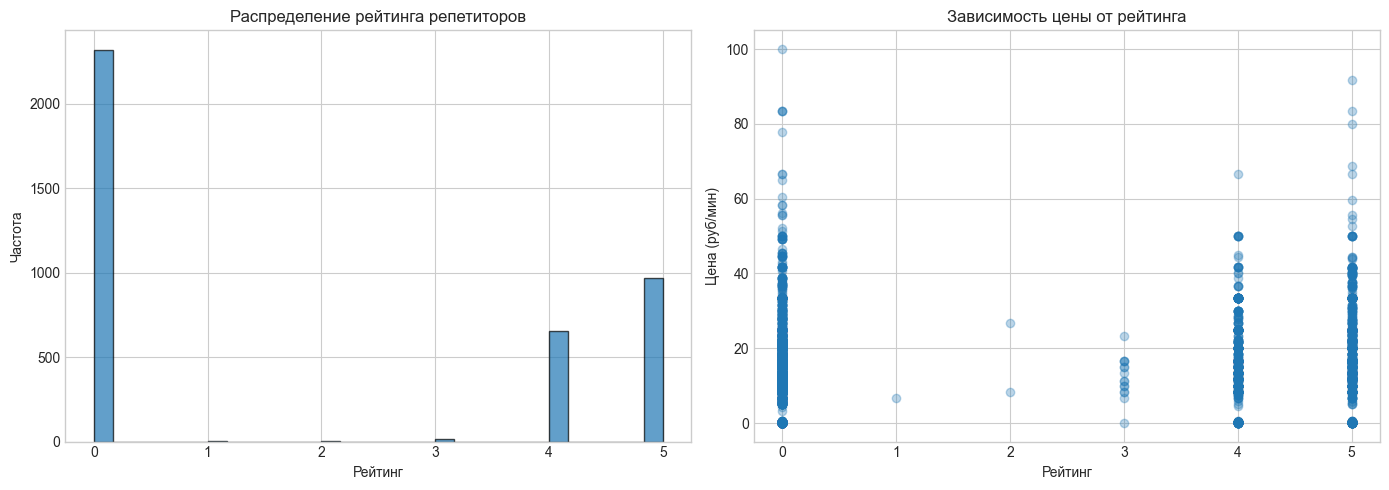

In [230]:
if 'tutor_rating' in train.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(train['tutor_rating'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Рейтинг')
    axes[0].set_ylabel('Частота')
    axes[0].set_title('Распределение рейтинга репетиторов')
    
    axes[1].scatter(train['tutor_rating'], train['mean_price'], alpha=0.3)
    axes[1].set_xlabel('Рейтинг')
    axes[1].set_ylabel('Цена (руб/мин)')
    axes[1].set_title('Зависимость цены от рейтинга')
    
    plt.tight_layout()
    plt.show()

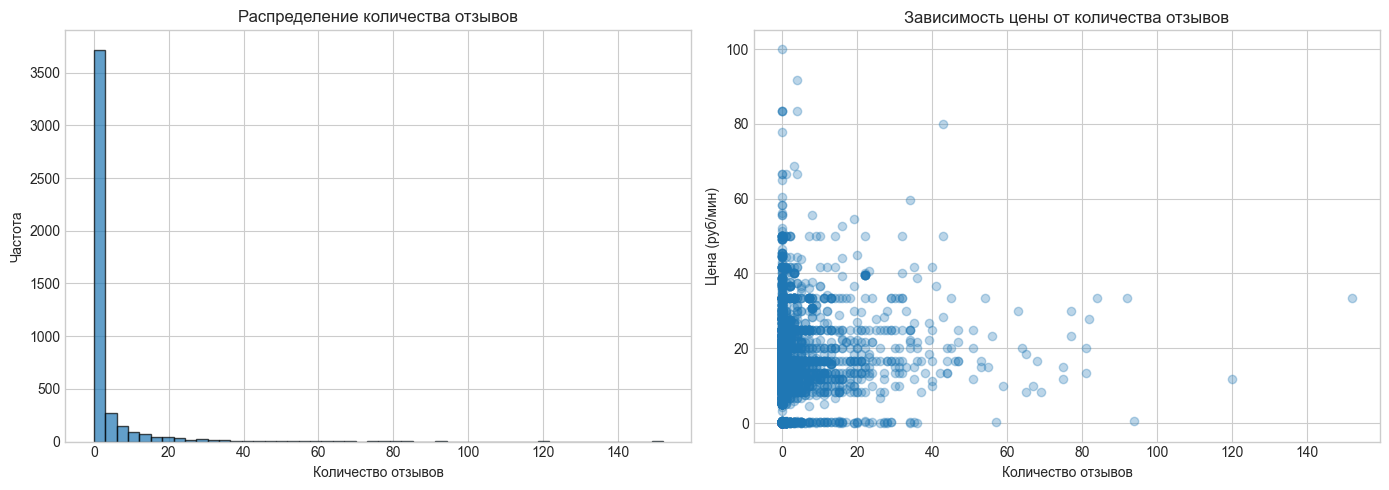

In [231]:
if 'tutor_reviews' in train.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(train['tutor_reviews'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Количество отзывов')
    axes[0].set_ylabel('Частота')
    axes[0].set_title('Распределение количества отзывов')
    
    axes[1].scatter(train['tutor_reviews'], train['mean_price'], alpha=0.3)
    axes[1].set_xlabel('Количество отзывов')
    axes[1].set_ylabel('Цена (руб/мин)')
    axes[1].set_title('Зависимость цены от количества отзывов')
    
    plt.tight_layout()
    plt.show()

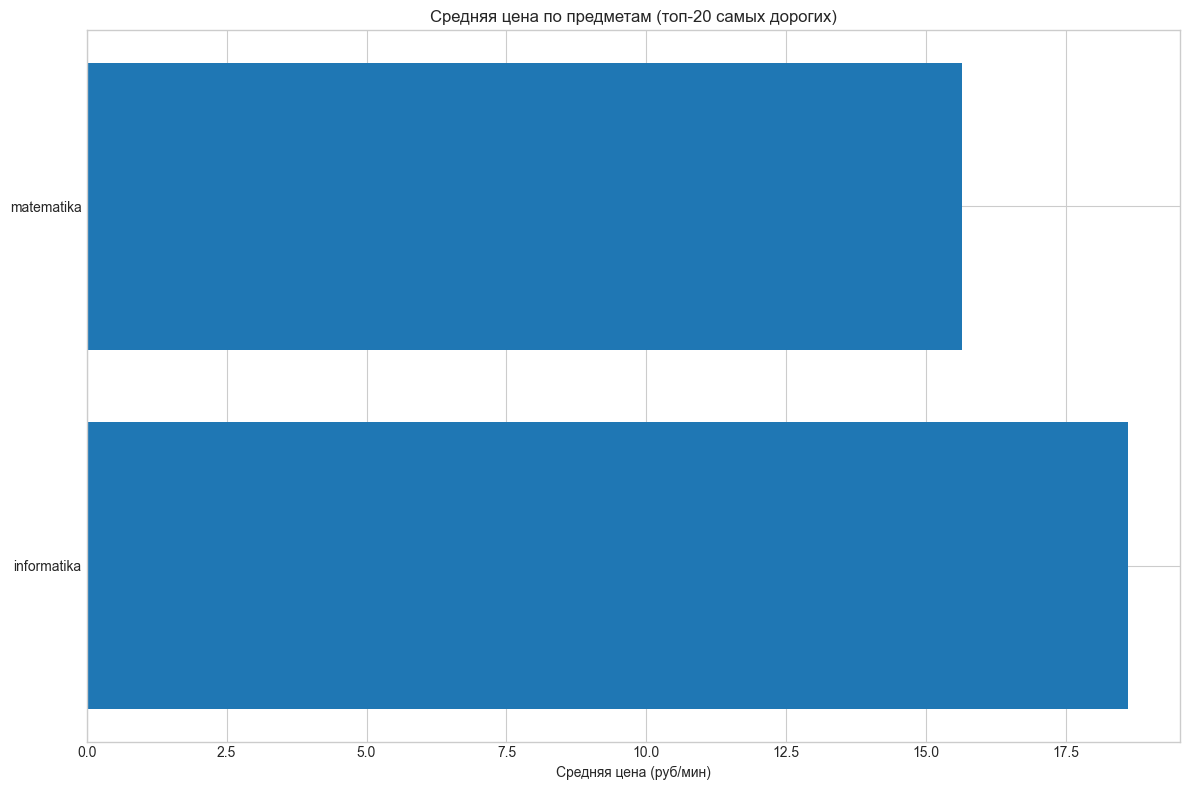

In [232]:
if 'предмет' in train.columns:
    price_by_subject = train.groupby('предмет')['mean_price'].agg(['mean', 'median', 'count'])
    price_by_subject = price_by_subject[price_by_subject['count'] >= 10].sort_values('mean', ascending=False)
    
    plt.figure(figsize=(12, 8))
    top_subjects = price_by_subject.head(20)
    plt.barh(range(len(top_subjects)), top_subjects['mean'])
    plt.yticks(range(len(top_subjects)), top_subjects.index)
    plt.xlabel('Средняя цена (руб/мин)')
    plt.title('Средняя цена по предметам (топ-20 самых дорогих)')
    plt.tight_layout()
    plt.show()

**Вывод:** цена зависит от предмета, рейтинга и отзывов. Данные требуют обработки пропусков.

## Предобработка данных

In [233]:
train_processed = train.copy()
test_processed = test.copy()

if 'index' not in test_processed.columns:
    test_processed['index'] = test_processed.index
test_indices = test_processed['index'].values

In [234]:
target = train_processed['mean_price']

cols_to_drop = ['mean_price']
if 'ФИО' in train_processed.columns:
    cols_to_drop.append('ФИО')
if 'index' in train_processed.columns:
    cols_to_drop.append('index')

train_processed = train_processed.drop(columns=[c for c in cols_to_drop if c in train_processed.columns])
test_processed = test_processed.drop(columns=[c for c in cols_to_drop if c in test_processed.columns and c != 'index'])
if 'index' in test_processed.columns:
    test_processed = test_processed.drop(columns=['index'])

In [235]:
numeric_cols = train_processed.select_dtypes(include=[np.number]).columns.tolist()
text_cols = train_processed.select_dtypes(include=['object']).columns.tolist()

print(f"Числовые признаки ({len(numeric_cols)}): {numeric_cols}")
print(f"\nТекстовые признаки ({len(text_cols)}): {text_cols}")

Числовые признаки (3): ['Unnamed: 0', 'tutor_rating', 'tutor_reviews']

Текстовые признаки (23): ['предмет', 'tutor_head_tags', 'description', 'experience_desc', 'Education_1', 'Desc_Education_1', 'Education_2', 'Desc_Education_2', 'Education_3', 'Desc_Education_3', 'Education_4', 'Desc_Education_4', 'Ученая степень 1', 'Ученое звание 1', 'status', 'experience', 'Desc_Education_5', 'Desc_Education_6', 'Education_5', 'Education_6', 'Ученая степень 2', 'Ученое звание 2', 'categories']


### Обработка числовых признаков

In [236]:
for col in numeric_cols:
    if train_processed[col].isnull().any():
        median_val = train_processed[col].median()
        train_processed[col] = train_processed[col].fillna(median_val)
        test_processed[col] = test_processed[col].fillna(median_val)

print("Пропуски в числовых признаках заполнены медианой")

Пропуски в числовых признаках заполнены медианой


### Обработка текстовых признаков

In [237]:
for col in text_cols:
    train_processed[col] = train_processed[col].fillna('')
    test_processed[col] = test_processed[col].fillna('')

print("Пропуски в текстовых признаках заполнены пустой строкой")

Пропуски в текстовых признаках заполнены пустой строкой


## Feature Engineering

Создадим новые признаки из имеющихся данных

In [238]:
def create_features(df):
    df = df.copy()
    
    if 'description' in df.columns:
        df['description_length'] = df['description'].apply(lambda x: len(str(x)))
        df['description_word_count'] = df['description'].apply(lambda x: len(str(x).split()))
    
    if 'experience_desc' in df.columns:
        df['experience_length'] = df['experience_desc'].apply(lambda x: len(str(x)))
        df['experience_word_count'] = df['experience_desc'].apply(lambda x: len(str(x).split()))
    
    education_cols = [c for c in df.columns if c.startswith('Education')]
    if education_cols:
        df['num_educations'] = df[education_cols].apply(
            lambda row: sum(1 for val in row if val != '' and pd.notna(val)), axis=1
        )
    
    degree_cols = [c for c in df.columns if 'Ученая степень' in c or 'Ученое звание' in c]
    if degree_cols:
        df['has_academic_degree'] = df[degree_cols].apply(
            lambda row: 1 if any(val != '' and pd.notna(val) for val in row) else 0, axis=1
        )
    
    if 'tutor_head_tags' in df.columns:
        df['num_levels'] = df['tutor_head_tags'].apply(
            lambda x: len(str(x).split(',')) if x != '' else 0
        )
        df['has_ege'] = df['tutor_head_tags'].apply(
            lambda x: 1 if 'ЕГЭ' in str(x).upper() else 0
        )
        df['has_oge'] = df['tutor_head_tags'].apply(
            lambda x: 1 if 'ОГЭ' in str(x).upper() or 'ГИА' in str(x).upper() else 0
        )
    
    if 'categories' in df.columns:
        df['num_categories'] = df['categories'].apply(
            lambda x: len(str(x).split(',')) if x != '' else 0
        )
    
    return df

train_processed = create_features(train_processed)
test_processed = create_features(test_processed)

print("Новые признаки созданы")

Новые признаки созданы


In [239]:
new_features = ['description_length', 'description_word_count', 'experience_length', 
                'experience_word_count', 'num_educations', 'has_academic_degree',
                'num_levels', 'has_ege', 'has_oge', 'num_categories']
existing_new_features = [f for f in new_features if f in train_processed.columns]

if existing_new_features:
    print("Корреляция новых признаков с целевой переменной:")
    for feat in existing_new_features:
        corr = train_processed[feat].corr(target)
        print(f"{feat}: {corr:.4f}")

Корреляция новых признаков с целевой переменной:
description_length: 0.2592
description_word_count: 0.2575
experience_length: 0.2181
experience_word_count: 0.2118
num_educations: 0.1066
has_academic_degree: 0.1358
num_levels: 0.0699
has_ege: 0.1635
has_oge: 0.0614
num_categories: 0.1978


### Кодирование категориального признака "предмет"

In [240]:
if 'предмет' in train_processed.columns:
    subject_mean_price = train.groupby('предмет')['mean_price'].mean().to_dict()
    global_mean = target.mean()
    
    train_processed['subject_encoded'] = train_processed['предмет'].map(subject_mean_price)
    test_processed['subject_encoded'] = test_processed['предмет'].map(subject_mean_price)
    test_processed['subject_encoded'] = test_processed['subject_encoded'].fillna(global_mean)
    
    print("Признак 'предмет' закодирован через target encoding")

Признак 'предмет' закодирован через target encoding


### TF-IDF для текстовых описаний

In [241]:
text_features_to_vectorize = []
if 'description' in train_processed.columns:
    text_features_to_vectorize.append('description')
if 'experience_desc' in train_processed.columns:
    text_features_to_vectorize.append('experience_desc')

tfidf_features_train = []
tfidf_features_test = []
tfidf_feature_names = []

for text_col in text_features_to_vectorize:
    tfidf = TfidfVectorizer(max_features=50, min_df=5, max_df=0.95, ngram_range=(1, 2))
    
    tfidf_train = tfidf.fit_transform(train_processed[text_col].astype(str))
    tfidf_test = tfidf.transform(test_processed[text_col].astype(str))
    
    feature_names = [f"{text_col}_tfidf_{name}" for name in tfidf.get_feature_names_out()]
    
    tfidf_train_df = pd.DataFrame(tfidf_train.toarray(), columns=feature_names, index=train_processed.index)
    tfidf_test_df = pd.DataFrame(tfidf_test.toarray(), columns=feature_names, index=test_processed.index)
    
    tfidf_features_train.append(tfidf_train_df)
    tfidf_features_test.append(tfidf_test_df)
    tfidf_feature_names.extend(feature_names)
    
    print(f"TF-IDF для '{text_col}': {len(feature_names)} признаков")

if tfidf_features_train:
    tfidf_train_combined = pd.concat(tfidf_features_train, axis=1)
    tfidf_test_combined = pd.concat(tfidf_features_test, axis=1)

TF-IDF для 'description': 50 признаков
TF-IDF для 'experience_desc': 50 признаков


### Формирование финального набора признаков

In [242]:
numeric_cols_updated = train_processed.select_dtypes(include=[np.number]).columns.tolist()

X_train_numeric = train_processed[numeric_cols_updated]
X_test_numeric = test_processed[numeric_cols_updated]

if tfidf_features_train:
    X_train = pd.concat([X_train_numeric.reset_index(drop=True), 
                         tfidf_train_combined.reset_index(drop=True)], axis=1)
    X_test = pd.concat([X_test_numeric.reset_index(drop=True), 
                        tfidf_test_combined.reset_index(drop=True)], axis=1)
else:
    X_train = X_train_numeric
    X_test = X_test_numeric

y_train = target

print(f"Итоговый размер тренировочного набора: {X_train.shape}")
print(f"Итоговый размер тестового набора: {X_test.shape}")

Итоговый размер тренировочного набора: (4548, 114)
Итоговый размер тестового набора: (1516, 114)


In [243]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

X_train = X_train.replace([np.inf, -np.inf], 0)
X_test = X_test.replace([np.inf, -np.inf], 0)

print("Данные очищены от пропусков и бесконечных значений")

Данные очищены от пропусков и бесконечных значений


**Вывод:** пропуски заполнены, созданы признаки из текстов (длина, TF-IDF) и категорий (target encoding).

## Разделение данных для валидации

In [244]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=RANDOM_STATE)

print(f"Размер обучающей выборки: {X_tr.shape}")
print(f"Размер валидационной выборки: {X_val.shape}")

Размер обучающей выборки: (3638, 114)
Размер валидационной выборки: (910, 114)


### Масштабирование признаков

In [245]:
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Признаки масштабированы с помощью StandardScaler")

Признаки масштабированы с помощью StandardScaler


## Обучение моделей

Попробуем несколько вариантов линейной регрессии и сравним их

In [246]:
def evaluate_model(model, X_tr, y_tr, X_val, y_val, model_name):
    model.fit(X_tr, y_tr)
    
    y_pred_tr = model.predict(X_tr)
    y_pred_val = model.predict(X_val)
    
    mse_tr = mean_squared_error(y_tr, y_pred_tr)
    mse_val = mean_squared_error(y_val, y_pred_val)
    rmse_tr = np.sqrt(mse_tr)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_val, y_pred_val)
    r2_val = r2_score(y_val, y_pred_val)
    
    print(f"\n{model_name}:")
    print(f"  Train RMSE: {rmse_tr:.4f}")
    print(f"  Val RMSE:   {rmse_val:.4f}")
    print(f"  Val MAE:    {mae_val:.4f}")
    print(f"  Val R2:     {r2_val:.4f}")
    
    return {'model': model, 'rmse_val': rmse_val, 'mse_val': mse_val, 'r2_val': r2_val}

### Базовая линейная регрессия

In [247]:
results = {}

lr = LinearRegression()
results['LinearRegression'] = evaluate_model(lr, X_tr_scaled, y_tr, X_val_scaled, y_val, 'Linear Regression')


Linear Regression:
  Train RMSE: 9.3005
  Val RMSE:   9.2520
  Val MAE:    6.6646
  Val R2:     0.1675


### Ridge регрессия (L2 регуляризация)

In [248]:
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
results['Ridge'] = evaluate_model(ridge, X_tr_scaled, y_tr, X_val_scaled, y_val, 'Ridge Regression (alpha=1.0)')


Ridge Regression (alpha=1.0):
  Train RMSE: 9.3019
  Val RMSE:   9.2461
  Val MAE:    6.6626
  Val R2:     0.1686


### Lasso регрессия (L1 регуляризация)

In [249]:
lasso = Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=50000, tol=1e-3)
results['Lasso'] = evaluate_model(lasso, X_tr_scaled, y_tr, X_val_scaled, y_val, 'Lasso Regression (alpha=0.1)')


Lasso Regression (alpha=0.1):
  Train RMSE: 9.3642
  Val RMSE:   9.1665
  Val MAE:    6.6064
  Val R2:     0.1829


### ElasticNet (комбинация L1 и L2)

In [250]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=50000, tol=1e-3)
results['ElasticNet'] = evaluate_model(elastic, X_tr_scaled, y_tr, X_val_scaled, y_val, 'ElasticNet (alpha=0.1, l1_ratio=0.5)')


ElasticNet (alpha=0.1, l1_ratio=0.5):
  Train RMSE: 9.3441
  Val RMSE:   9.1699
  Val MAE:    6.6058
  Val R2:     0.1822


### Сравнение моделей

In [251]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Val RMSE': [results[m]['rmse_val'] for m in results],
    'Val MSE': [results[m]['mse_val'] for m in results],
    'Val R2': [results[m]['r2_val'] for m in results]
}).sort_values('Val RMSE')

print("Сравнение моделей (отсортировано по RMSE):")
comparison_df

Сравнение моделей (отсортировано по RMSE):


,Model,Val RMSE,Val MSE,Val R2
2,Lasso,9.166479,84.024345,0.182855
3,ElasticNet,9.169919,84.087421,0.182242
1,Ridge,9.246051,85.489462,0.168607
0,LinearRegression,9.251957,85.598708,0.167545


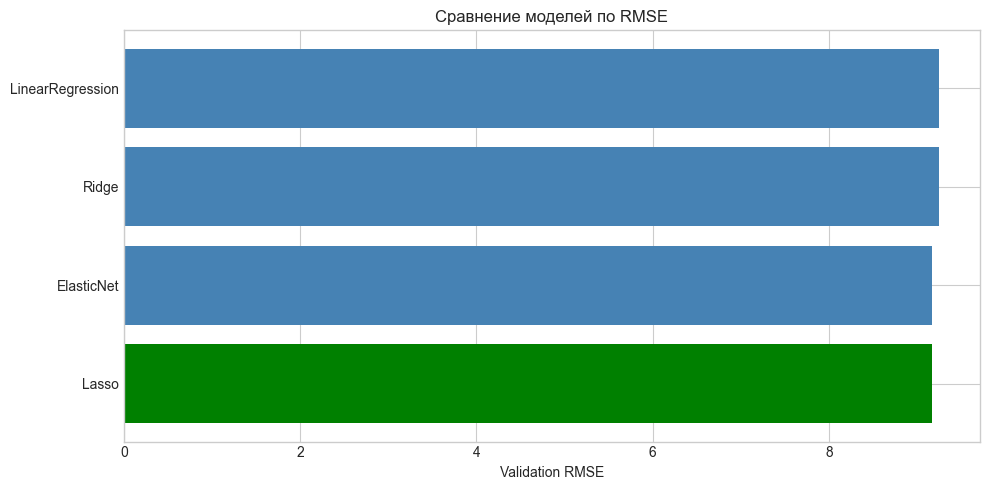

In [252]:
plt.figure(figsize=(10, 5))
colors = ['green' if i == 0 else 'steelblue' for i in range(len(comparison_df))]
plt.barh(comparison_df['Model'], comparison_df['Val RMSE'], color=colors)
plt.xlabel('Validation RMSE')
plt.title('Сравнение моделей по RMSE')
plt.tight_layout()
plt.show()

**Вывод:** модели с регуляризацией (Ridge, Lasso) работают стабильнее базовой линейной регрессии.

## Подбор гиперпараметров

In [253]:
print("Подбор alpha для Ridge регрессии...")

ridge_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
ridge_grid = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_params, 
                          cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_tr_scaled, y_tr)

print(f"Лучший параметр: {ridge_grid.best_params_}")
print(f"Лучший CV MSE: {-ridge_grid.best_score_:.4f}")
print(f"Лучший CV RMSE: {np.sqrt(-ridge_grid.best_score_):.4f}")

Подбор alpha для Ridge регрессии...
Лучший параметр: {'alpha': 100.0}
Лучший CV MSE: 94.1228
Лучший CV RMSE: 9.7017


In [254]:
print("Подбор alpha для Lasso регрессии...")

lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
lasso_grid = GridSearchCV(Lasso(random_state=RANDOM_STATE, max_iter=50000, tol=1e-3), lasso_params, 
                          cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
lasso_grid.fit(X_tr_scaled, y_tr)

print(f"Лучший параметр: {lasso_grid.best_params_}")
print(f"Лучший CV MSE: {-lasso_grid.best_score_:.4f}")
print(f"Лучший CV RMSE: {np.sqrt(-lasso_grid.best_score_):.4f}")

Подбор alpha для Lasso регрессии...
Лучший параметр: {'alpha': 0.1}
Лучший CV MSE: 92.4457
Лучший CV RMSE: 9.6149


In [255]:
print("Подбор параметров для ElasticNet...")

elastic_params = {
    'alpha': [0.001, 0.01, 0.1, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
elastic_grid = GridSearchCV(ElasticNet(random_state=RANDOM_STATE, max_iter=50000, tol=1e-3), elastic_params, 
                            cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
elastic_grid.fit(X_tr_scaled, y_tr)

print(f"Лучшие параметры: {elastic_grid.best_params_}")
print(f"Лучший CV MSE: {-elastic_grid.best_score_:.4f}")
print(f"Лучший CV RMSE: {np.sqrt(-elastic_grid.best_score_):.4f}")

Подбор параметров для ElasticNet...
Лучшие параметры: {'alpha': 0.1, 'l1_ratio': 0.9}
Лучший CV MSE: 92.5126
Лучший CV RMSE: 9.6183


### Оценка лучших моделей на валидации

In [256]:
best_models = {
    'Ridge_tuned': ridge_grid.best_estimator_,
    'Lasso_tuned': lasso_grid.best_estimator_,
    'ElasticNet_tuned': elastic_grid.best_estimator_
}

tuned_results = {}
for name, model in best_models.items():
    y_pred = model.predict(X_val_scaled)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    tuned_results[name] = {'rmse': rmse, 'mse': mse}
    print(f"{name}: Val RMSE = {rmse:.4f}")

Ridge_tuned: Val RMSE = 9.2044
Lasso_tuned: Val RMSE = 9.1665
ElasticNet_tuned: Val RMSE = 9.1654


## Выбор лучшей модели

Сравним все модели и выберем лучшую

In [257]:
all_results = {
    'LinearRegression': results['LinearRegression']['rmse_val'],
    'Ridge': results['Ridge']['rmse_val'],
    'Lasso': results['Lasso']['rmse_val'],
    'ElasticNet': results['ElasticNet']['rmse_val'],
    'Ridge_tuned': tuned_results['Ridge_tuned']['rmse'],
    'Lasso_tuned': tuned_results['Lasso_tuned']['rmse'],
    'ElasticNet_tuned': tuned_results['ElasticNet_tuned']['rmse']
}

best_model_name = min(all_results, key=all_results.get)
print(f"\nЛучшая модель: {best_model_name} с RMSE = {all_results[best_model_name]:.4f}")


Лучшая модель: ElasticNet_tuned с RMSE = 9.1654


In [258]:
if 'tuned' in best_model_name:
    if 'Ridge' in best_model_name:
        final_model = ridge_grid.best_estimator_
    elif 'Lasso' in best_model_name:
        final_model = lasso_grid.best_estimator_
    else:
        final_model = elastic_grid.best_estimator_
else:
    final_model = results[best_model_name]['model']

print(f"Финальная модель: {type(final_model).__name__}")
print(f"Параметры: {final_model.get_params()}")

Финальная модель: ElasticNet
Параметры: {'alpha': 0.1, 'copy_X': True, 'fit_intercept': True, 'l1_ratio': 0.9, 'max_iter': 50000, 'positive': False, 'precompute': False, 'random_state': 33, 'selection': 'cyclic', 'tol': 0.001, 'warm_start': False}


**Вывод:** выбрана модель с лучшим RMSE на валидации. Регуляризация помогает при большом числе признаков.

## Анализ важности признаков

In [259]:
if hasattr(final_model, 'coef_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'coefficient': final_model.coef_
    })
    feature_importance['abs_coef'] = np.abs(feature_importance['coefficient'])
    feature_importance = feature_importance.sort_values('abs_coef', ascending=False)
    
    print("Топ-20 важных признаков по абсолютному значению коэффициента:")
    print(feature_importance.head(20))

Топ-20 важных признаков по абсолютному значению коэффициента:
                                       feature  coefficient  abs_coef
80                   experience_desc_tfidf_лет     1.453105  1.453105
3                           description_length     1.355148  1.355148
8                          has_academic_degree     1.034443  1.034443
1                                 tutor_rating     0.988069  0.988069
12                              num_categories     0.771220  0.771220
5                            experience_length     0.723833  0.723833
2                                tutor_reviews     0.575408  0.575408
7                               num_educations     0.510504  0.510504
70                  experience_desc_tfidf_года     0.510433  0.510433
107             experience_desc_tfidf_учеников     0.485540  0.485540
36                       description_tfidf_огэ     0.465486  0.465486
24                   description_tfidf_занятий     0.450788  0.450788
109  experience_desc_tfidf_у

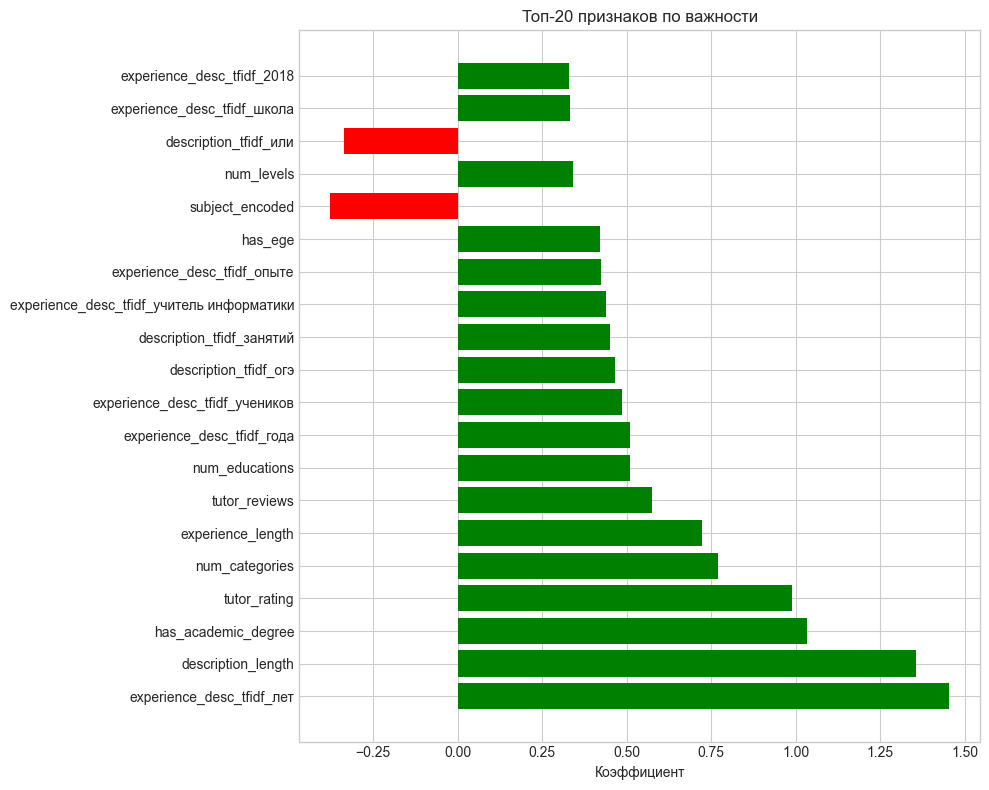

In [260]:
if hasattr(final_model, 'coef_'):
    top_features = feature_importance.head(20)
    
    plt.figure(figsize=(10, 8))
    colors = ['green' if c > 0 else 'red' for c in top_features['coefficient']]
    plt.barh(range(len(top_features)), top_features['coefficient'], color=colors)
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Коэффициент')
    plt.title('Топ-20 признаков по важности')
    plt.tight_layout()
    plt.show()

## Обучение финальной модели на всех данных

In [261]:
scaler_final = StandardScaler()
X_train_scaled_final = scaler_final.fit_transform(X_train)
X_test_scaled_final = scaler_final.transform(X_test)

final_model.fit(X_train_scaled_final, y_train)

print("Модель обучена на всём тренировочном наборе")

Модель обучена на всём тренировочном наборе


## Предсказание на тестовых данных

In [262]:
test_predictions = final_model.predict(X_test_scaled_final)

test_predictions = np.maximum(test_predictions, 0)

print(f"Статистика предсказаний:")
print(f"  Min: {test_predictions.min():.4f}")
print(f"  Max: {test_predictions.max():.4f}")
print(f"  Mean: {test_predictions.mean():.4f}")
print(f"  Std: {test_predictions.std():.4f}")

Статистика предсказаний:
  Min: 7.6432
  Max: 56.3627
  Mean: 16.2131
  Std: 4.5753


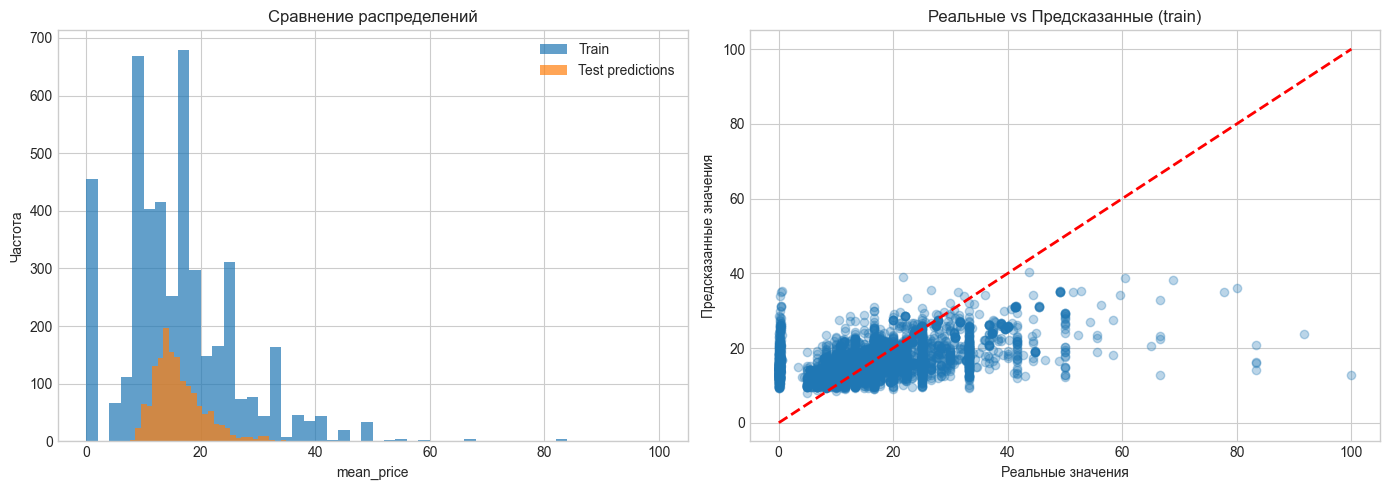

In [263]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train, bins=50, alpha=0.7, label='Train')
axes[0].hist(test_predictions, bins=50, alpha=0.7, label='Test predictions')
axes[0].set_xlabel('mean_price')
axes[0].set_ylabel('Частота')
axes[0].set_title('Сравнение распределений')
axes[0].legend()

y_train_pred = final_model.predict(X_train_scaled_final)
axes[1].scatter(y_train, y_train_pred, alpha=0.3)
axes[1].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[1].set_xlabel('Реальные значения')
axes[1].set_ylabel('Предсказанные значения')
axes[1].set_title('Реальные vs Предсказанные (train)')

plt.tight_layout()
plt.show()

## Создание файла для отправки

In [264]:
submission = pd.DataFrame({
    'index': test_indices,
    'mean_price': test_predictions
})

submission.to_csv('submission.csv', index=False)

print("Файл submission.csv создан")
print(f"\nПервые строки файла:")
submission.head(10)

Файл submission.csv создан

Первые строки файла:


,index,mean_price
0,0,15.032934
1,1,12.904289
2,2,15.469839
3,3,13.816252
4,4,14.233522
5,5,10.259017
6,6,15.190696
7,7,13.231037
8,8,16.957152
9,9,16.675362


In [265]:
print(f"Размер submission: {submission.shape}")
print(f"Пропуски: {submission.isnull().sum().sum()}")

Размер submission: (1516, 2)
Пропуски: 0


## Итоговые выводы

- Предмет, рейтинг и отзывы - это главные факторы цены
- Созданы признаки из текстов (TF-IDF) и категорий (target encoding)
- Лучший результат показала модель с регуляризацией
- Подбор гиперпараметров улучшил качество

## Скриншот с Kaggle

![Kaggle Score](image.png)